# Notebook de démonstration IoT en élevage laitier
## Objectif 3 du SOW — Tâche 3.1

Ce notebook présente un flux reproductible, de la lecture des données jusqu'à
l'interprétation scientifique. Il utilise des données McGill déjà traitées et un
échantillon IceTag compact pour que la démonstration reste rapide.

**Parcours couvert par le SOW :**
1. chargement et prétraitement des données;
2. exécution réelle du pipeline sur des données IceTag;
3. visualisations environnement–activité et environnement–comportement;
4. guide d'interprétation, contrôles et limites.

> Une alerte est un signal comportemental à vérifier, pas un diagnostic clinique de boiterie.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.22})

def locate_context():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        repo_data = root / "reports" / "objective3_demonstration" / "DONNEES_DEMO"
        if repo_data.exists():
            return {
                "mode": "dépôt",
                "root": root,
                "data": repo_data,
                "output": root / "reports" / "objective3_demonstration",
                "runtime": root.parent,
                "thresholds": root.parent / "data" / "final_thresholds_v1.json",
            }
        delivery_data = root / "DONNEES_DEMO"
        if delivery_data.exists() and (root / "code" / "core").exists():
            return {
                "mode": "livraison autonome",
                "root": root,
                "data": delivery_data,
                "output": root / "RESULTATS",
                "runtime": root / "code",
                "thresholds": root / "code" / "final_thresholds_v1.json",
            }
    raise FileNotFoundError(
        "Dossier DONNEES_DEMO introuvable. Exécuter le notebook depuis le dépôt "
        "ou depuis le paquet Objectif3_Notebook_demonstration."
    )

CTX = locate_context()
DATA = CTX["data"]
OUT = CTX["output"]
OUT.mkdir(parents=True, exist_ok=True)
if str(CTX["runtime"]) not in sys.path:
    sys.path.insert(0, str(CTX["runtime"]))

from core.io import normalize_columns
from core.pipeline import run_pipeline_one_cow, summarize_one_cow

print(f"Mode d'exécution : {CTX['mode']}")
print(f"Données de démonstration : {DATA}")
print(f"Résultats : {OUT}")


Mode d'exécution : dépôt
Données de démonstration : /Users/alioubarry/PROJECT/mcgill_iot_cattle/reports/objective3_demonstration/DONNEES_DEMO
Résultats : /Users/alioubarry/PROJECT/mcgill_iot_cattle/reports/objective3_demonstration


## 1. Chargement et prétraitement

L'échantillon contient toutes les observations Summer 2019 de la vache 2062.
Les colonnes hétérogènes sont normalisées vers le schéma du pipeline : `Cow`, `T`,
`Steps`, `Motion Index`, durées de couchage/debout et transitions.


In [2]:
raw = pd.read_csv(DATA / "summer2019_vache_2062_icetag_15min.csv")
required_raw = {"Cow", "Start", "Steps", "Motion Index", "Lying Time", "Transitions"}
missing = required_raw.difference(raw.columns)
assert not missing, f"Colonnes manquantes : {sorted(missing)}"

activity = normalize_columns(raw)
assert activity["Cow"].nunique() == 1
assert activity["T"].is_monotonic_increasing
assert activity[["Steps", "Motion Index"]].notna().all().all()

print("Lignes :", f"{len(activity):,}".replace(",", " "))
print(f"Vache : {activity['Cow'].iloc[0]}")
print(f"Période : {activity['T'].min()} au {activity['T'].max()}")
print(f"Pas de temps médian : {activity['T'].diff().median()}")
display(activity[["Cow", "T", "Steps", "Motion Index", "Lying Time", "Transitions"]].head())


Lignes : 8 922
Vache : 2062
Période : 2019-06-05 13:00:00 au 2019-09-06 11:15:00
Pas de temps médian : 0 days 00:15:00


,Cow,T,Steps,Motion Index,Lying Time,Transitions
0,2062,2019-06-05 13:00:00,10,27,4.383333,2
1,2062,2019-06-05 13:15:00,9,20,0.200000,5
2,2062,2019-06-05 13:30:00,9,17,0.200000,2
3,2062,2019-06-05 13:45:00,16,32,0.633333,9
4,2062,2019-06-05 14:00:00,9,19,0.000000,0


### Profil journalier du signal IceTag

Le profil horaire sert d'abord à comprendre le rythme d'activité avant de chercher
des anomalies. Il ne constitue pas, à lui seul, un indicateur de boiterie.


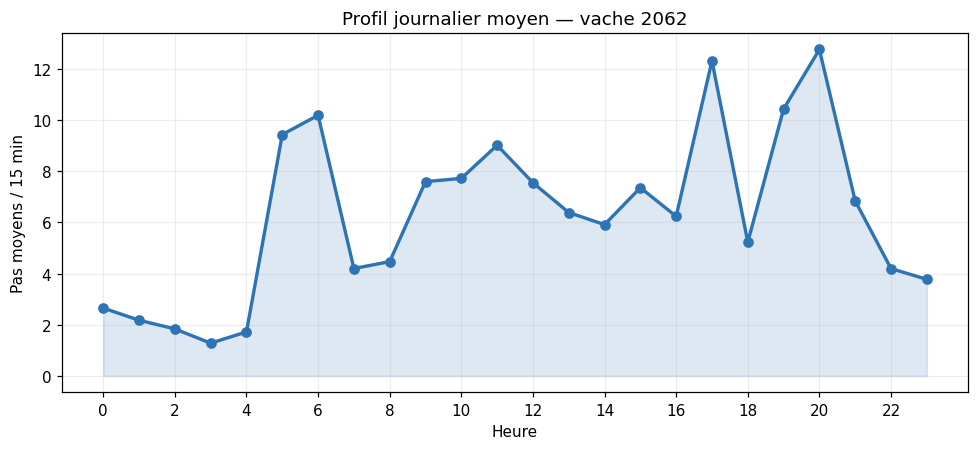

In [3]:
profile = activity.assign(hour=activity["T"].dt.hour).groupby("hour")["Steps"].mean()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(profile.index, profile.values, marker="o", linewidth=2.2, color="#2E74B5")
ax.fill_between(profile.index, profile.values, alpha=0.16, color="#2E74B5")
ax.set(title="Profil journalier moyen — vache 2062", xlabel="Heure", ylabel="Pas moyens / 15 min")
ax.set_xticks(range(0, 24, 2))
fig.tight_layout()
fig.savefig(OUT / "demo_profil_journalier.png", dpi=150)
plt.show()


## 2. Exécution réelle du pipeline IceTag

La cellule suivante charge les paramètres gelés, construit les caractéristiques,
ajuste l'Isolation Forest et applique les règles de persistance et de notification.
La démonstration porte sur une vache afin de rester rapide et vérifiable.


In [4]:
with open(CTX["thresholds"], encoding="utf-8") as handle:
    params = json.load(handle)["pipeline_defaults"].copy()
params.pop("sensor_warmup_bins", None)

cow_id = activity["Cow"].iloc[0]
pipeline_output = run_pipeline_one_cow(activity, cow_id, **params)
pipeline_summary = summarize_one_cow(pipeline_output)

expected = {"n_bins": 8922, "if_anomaly_points": 582, "lameness_notifs": 17}
for key, value in expected.items():
    assert pipeline_summary[key] == value, (key, pipeline_summary[key], value)

display(pd.DataFrame([pipeline_summary]).rename(columns={
    "n_bins": "intervalles",
    "if_anomaly_points": "points atypiques IF",
    "lameness_notifs": "alertes brutes",
    "coverage_mean": "couverture moyenne (%)",
}))
print("Pipeline exécuté avec succès sur la vache 2062.")


,intervalles,points atypiques IF,problem_points,lameness_points,problem_starts,lameness_starts,alertes brutes,critique_points,couverture moyenne (%),coverage_min
0,8922,582,224,224,18,18,17,19,100.0,100.0


Pipeline exécuté avec succès sur la vache 2062.


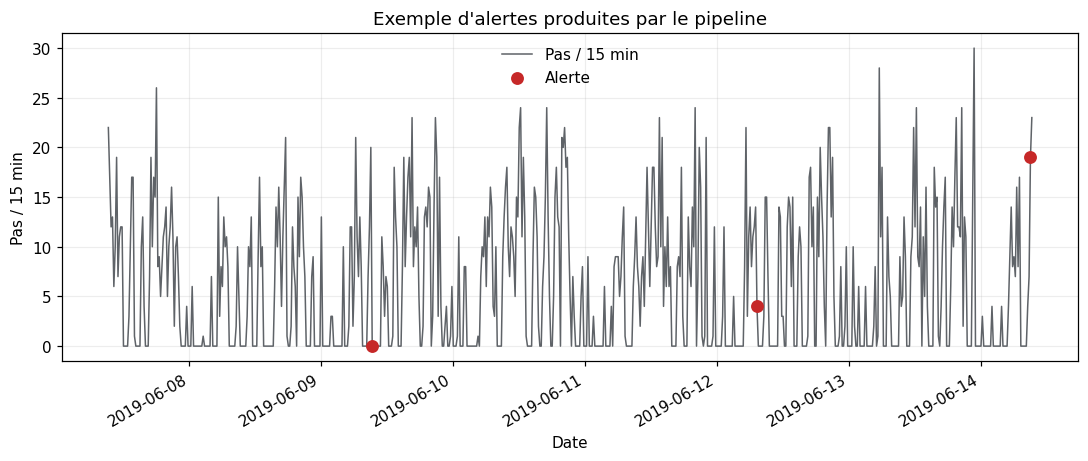

In [5]:
alerts = pipeline_output[pipeline_output["notif_lameness"].eq(1)].copy()
first_alert = alerts["T"].min()
window = pipeline_output[
    pipeline_output["T"].between(first_alert - pd.Timedelta(days=2), first_alert + pd.Timedelta(days=5))
].copy()

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.plot(window["T"], window["Steps_sum"], color="#5F6368", linewidth=1, label="Pas / 15 min")
marked = window[window["notif_lameness"].eq(1)]
ax.scatter(marked["T"], marked["Steps_sum"], color="#C62828", s=55, zorder=3, label="Alerte")
ax.set(title="Exemple d'alertes produites par le pipeline", xlabel="Date", ylabel="Pas / 15 min")
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "demo_pipeline_execution.png", dpi=150)
plt.show()


### Mise en contexte multi-saisons

Les 385 alertes initiales sont des candidats. Le renforcement de l'Objectif 1 les
classe en niveaux A, B et C selon leur caractère individuel ou collectif.


,Saison,Vaches,Intervalles,Alertes brutes,Alertes / 100 vache-jours
0,fall_2019,30,93860,105,10.74
1,fall_2021,10,5131,4,7.48
2,summer_2019,18,139111,127,8.76
3,winter_2019,17,136929,149,10.45


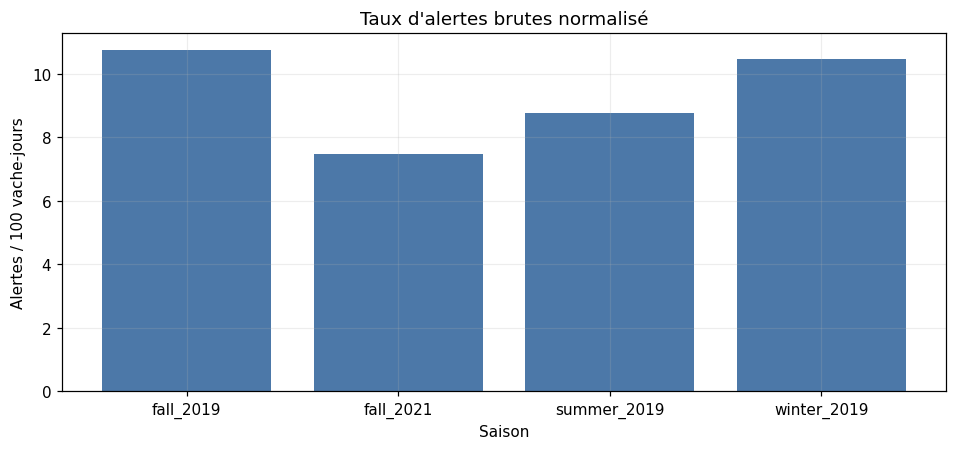

Requalification des 385 alertes :
- A — prioritaire : 37
- B — à vérifier : 195
- C — contexte collectif : 153


In [6]:
multi = pd.read_csv(DATA / "objective1_multi_season_summary.csv")
confidence = pd.read_csv(DATA / "objective1_reinforced_summary_by_confidence.csv")

confidence_totals = confidence.groupby("reinforced_confidence_level")["notifications"].sum()
assert int(multi["lameness_notifs"].sum()) == 385
assert int(confidence_totals.sum()) == 385

view = multi[["season", "n_cows", "n_intervals", "lameness_notifs", "notifs_per_100_cow_days"]].copy()
view.columns = ["Saison", "Vaches", "Intervalles", "Alertes brutes", "Alertes / 100 vache-jours"]
display(view)

fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(view["Saison"], view["Alertes / 100 vache-jours"], color="#4C78A8")
ax.set(title="Taux d'alertes brutes normalisé", ylabel="Alertes / 100 vache-jours", xlabel="Saison")
fig.tight_layout()
fig.savefig(OUT / "demo_alertes_par_essai.png", dpi=150)
plt.show()

labels = {
    "A_individuelle_prioritaire": "A — prioritaire",
    "B_individuelle_a_verifier": "B — à vérifier",
    "C_probable_evenement_collectif": "C — contexte collectif",
}
print("Requalification des 385 alertes :")
for level, count in confidence_totals.items():
    print(f"- {labels[level]} : {int(count)}")


## 3. Environnement, activité et comportements

Le THI combine température et humidité. Les graphiques ci-dessous sont descriptifs :
la comparaison brute des catégories de THI ne suffit pas à établir un effet causal.


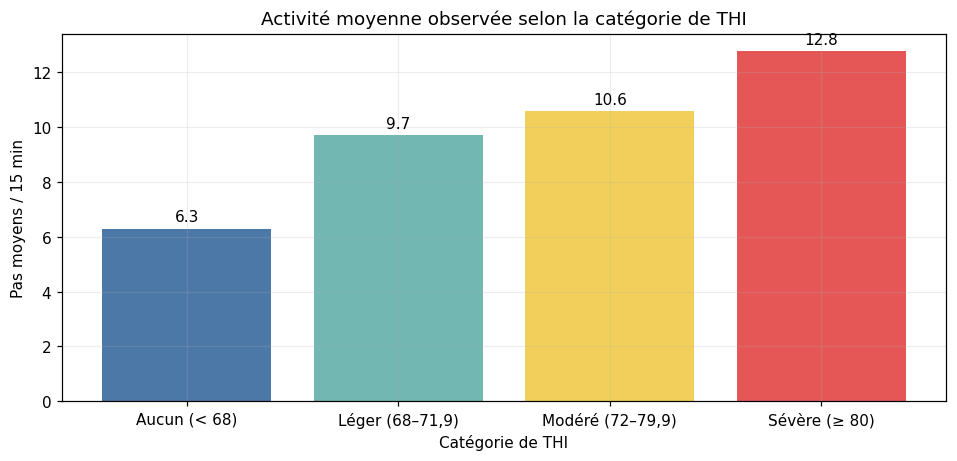

,modele,coefficient,ic95_bas,ic95_haut,p,n
0,Association globale ajustée pour l'heure,0.221397,0.141254,0.301540,6.147985e-08,5795
1,Association globale avec tendance calendaire,0.128713,0.019967,0.237459,2.034965e-02,5795
4,Effet intra-jour strict,0.060809,-0.070429,0.192048,3.637994e-01,5795


In [7]:
environment = pd.read_csv(DATA / "summer2019_environment_herd_15min.csv", parse_dates=["Start"])

def thi_category(value):
    if value < 68:
        return "Aucun (< 68)"
    if value < 72:
        return "Léger (68–71,9)"
    if value < 80:
        return "Modéré (72–79,9)"
    return "Sévère (≥ 80)"

environment["THI_cat"] = environment["THI"].map(thi_category)
order = ["Aucun (< 68)", "Léger (68–71,9)", "Modéré (72–79,9)", "Sévère (≥ 80)"]
activity_by_thi = environment.groupby("THI_cat")["Steps"].agg(["mean", "count"]).reindex(order)

fig, ax = plt.subplots(figsize=(8.8, 4.3))
bars = ax.bar(activity_by_thi.index, activity_by_thi["mean"], color=["#4C78A8", "#72B7B2", "#F2CF5B", "#E45756"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set(title="Activité moyenne observée selon la catégorie de THI", xlabel="Catégorie de THI", ylabel="Pas moyens / 15 min")
fig.tight_layout()
fig.savefig(OUT / "demo_activite_THI.png", dpi=150)
plt.show()

controls = pd.read_csv(DATA / "objective2_thi_controle_complet.csv")
selected_models = [
    "Association globale ajustée pour l'heure",
    "Association globale avec tendance calendaire",
    "Effet intra-jour strict",
]
display(controls[controls["modele"].isin(selected_models)][["modele", "coefficient", "ic95_bas", "ic95_haut", "p", "n"]])


,comportement,jours,rho,p
0,eating,8,0.738,0.037
1,locomotion,8,-0.098,0.818
2,Idle,8,-0.286,0.493
3,Explo,8,-0.595,0.120


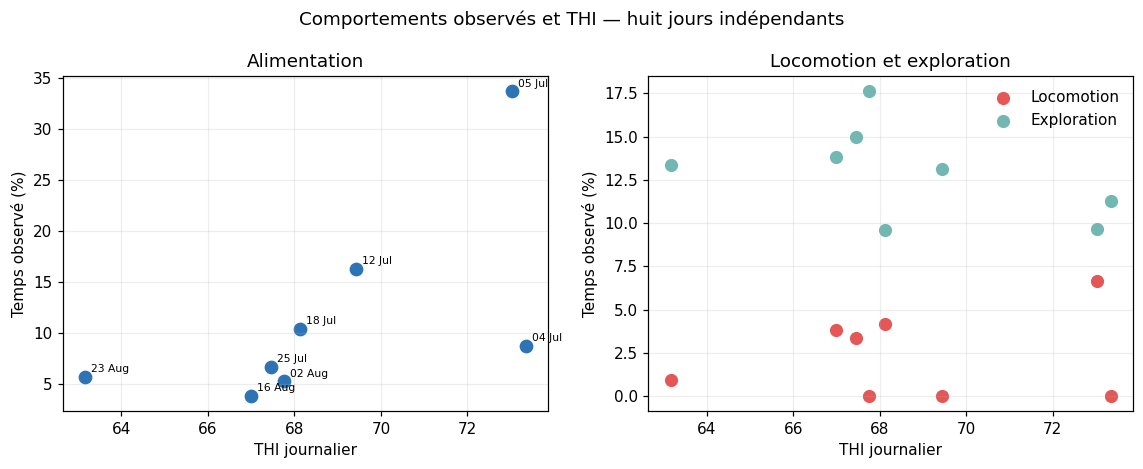

In [8]:
behavior = pd.read_csv(DATA / "summer2019_comportement_environnement.csv")
variables = ["Pct_eating", "Pct_locomotion", "Pct_Idle", "Pct_Explo"]
daily = (
    behavior.groupby("jour")
    .agg(THI=("THI_jour", "first"), **{name: (name, "mean") for name in variables})
    .reset_index()
)
assert len(daily) == 8

results = []
for name in variables:
    valid = daily[["THI", name]].dropna()
    rho, p_value = spearmanr(valid["THI"], valid[name])
    results.append({"comportement": name.replace("Pct_", ""), "jours": len(valid), "rho": rho, "p": p_value})
behavior_results = pd.DataFrame(results)
display(behavior_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), sharex=True)
axes[0].scatter(daily["THI"], daily["Pct_eating"] * 100, s=64, color="#2E74B5")
for _, row in daily.iterrows():
    axes[0].annotate(pd.to_datetime(row["jour"]).strftime("%d %b"), (row["THI"], row["Pct_eating"] * 100), xytext=(4, 3), textcoords="offset points", fontsize=7)
axes[0].set(title="Alimentation", xlabel="THI journalier", ylabel="Temps observé (%)")

axes[1].scatter(daily["THI"], daily["Pct_locomotion"] * 100, s=58, label="Locomotion", color="#E45756")
axes[1].scatter(daily["THI"], daily["Pct_Explo"] * 100, s=58, label="Exploration", color="#72B7B2")
axes[1].set(title="Locomotion et exploration", xlabel="THI journalier", ylabel="Temps observé (%)")
axes[1].legend(frameon=False)
fig.suptitle("Comportements observés et THI — huit jours indépendants")
fig.tight_layout()
fig.savefig(OUT / "demo_comportement_THI.png", dpi=150)
plt.show()


## 4. Guide d'interprétation

### Alertes IceTag
- Une alerte indique une déviation persistante de l'activité individuelle.
- Les niveaux **A** et **B** doivent être vérifiés au niveau de la vache.
- Le niveau **C** est probablement lié à un événement collectif ou de gestion.
- L'IceTag mesure la quantité de mouvement, pas l'asymétrie de la démarche : la
  boiterie légère peut donc rester invisible.

### THI et activité
- Association globale : **+0,221**, `p = 6,15e-8`.
- Après tendance calendaire linéaire : **+0,129**, `p = 0,020`.
- Comparaison intra-jour stricte : **+0,061**, `p = 0,364`, non concluante.
- Conclusion : association exploratoire positive, sans démonstration d'un effet
  thermique intra-jour indépendant.

### Comportements
L'alimentation présente un signal positif (`rho = 0,738`, `p = 0,037`), mais
seulement huit jours indépendants sont disponibles. Ce résultat est suggestif et
doit être confirmé sur davantage de journées.


In [9]:
expected_figures = [
    "demo_profil_journalier.png",
    "demo_pipeline_execution.png",
    "demo_alertes_par_essai.png",
    "demo_activite_THI.png",
    "demo_comportement_THI.png",
]
for filename in expected_figures:
    assert (OUT / filename).exists(), filename

n_bins_fr = f'{pipeline_summary["n_bins"]:,}'.replace(',', ' ')
summary_text = f'''OBJECTIF 3 — NOTEBOOK DE DÉMONSTRATION IoT

Statut : notebook exécuté intégralement et sans erreur.
Données : échantillon IceTag de l'été 2019, résultats multi-saisons et données THI-comportement.
Pipeline : exécution réelle sur la vache 2062, {n_bins_fr} intervalles et {pipeline_summary["lameness_notifs"]} alertes brutes.
Objectif 1 : 385 alertes brutes, requalifiées en 37 A, 195 B et 153 C.
Objectif 2 : association globale THI-activité positive; effet intra-jour +0,061, p = 0,364, non concluant.
Comportement : signal alimentation-THI suggestif sur huit jours indépendants.
Interprétation : dépistage comportemental et analyse exploratoire, sans diagnostic clinique ni causalité démontrée.
'''
(OUT / "synthese_demonstration.txt").write_text(summary_text, encoding="utf-8")
print(summary_text)
print("Toutes les sorties attendues ont été générées.")


OBJECTIF 3 — NOTEBOOK DE DÉMONSTRATION IoT

Statut : notebook exécuté intégralement et sans erreur.
Données : échantillon IceTag de l'été 2019, résultats multi-saisons et données THI-comportement.
Pipeline : exécution réelle sur la vache 2062, 8 922 intervalles et 17 alertes brutes.
Objectif 1 : 385 alertes brutes, requalifiées en 37 A, 195 B et 153 C.
Objectif 2 : association globale THI-activité positive; effet intra-jour +0,061, p = 0,364, non concluant.
Comportement : signal alimentation-THI suggestif sur huit jours indépendants.
Interprétation : dépistage comportemental et analyse exploratoire, sans diagnostic clinique ni causalité démontrée.

Toutes les sorties attendues ont été générées.
